# Machine Learning Project 


# Part A. Regression Modelling Requirement 

# 1. Library import and data loading

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
df_unclean=pd.read_csv('unclean_data.csv')
print(df_unclean)

         model    year     price transmission mileage fuel type engine size  \
0      C Class  2020.0   £30,495    Automatic     NaN    Diesel           2   
1      C Class  2020.0   £29,989    Automatic     NaN    Petrol         1.5   
2      C Class  2020.0   £37,899    Automatic     NaN    Diesel           2   
3      C Class  2019.0   £30,399    Automatic     NaN    Diesel           2   
4      C Class  2019.0   £29,899    Automatic     NaN    Diesel           2   
...        ...     ...       ...          ...     ...       ...         ...   
4001   C Class  2017.0   £14,700       Manual  31,357        25        £150   
4002   C Class  2018.0   £18,500    Automatic  28,248        31        £150   
4003   C Class  2014.0   £11,900       Manual  48,055        31         £20   
4004   C Class  2014.0   £11,300    Automatic  49,865        46        £145   
4005   C Class  2014.0   £14,800    Automatic  55,445        37         £30   

     mileage2 fuel type2 engine size2     reference

In [6]:
data=df_unclean

## Data rows and Columns

In [8]:
data.shape

(4006, 11)

## data types

In [10]:
data.dtypes

model            object
year            float64
price            object
transmission     object
mileage          object
fuel type        object
engine size      object
mileage2         object
fuel type2       object
engine size2     object
reference        object
dtype: object

## data information

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4006 entries, 0 to 4005
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         3907 non-null   object 
 1   year          3904 non-null   float64
 2   price         3907 non-null   object 
 3   transmission  3907 non-null   object 
 4   mileage       3808 non-null   object 
 5   fuel type     1329 non-null   object 
 6   engine size   3842 non-null   object 
 7   mileage2      3890 non-null   object 
 8   fuel type2    3808 non-null   object 
 9   engine size2  3808 non-null   object 
 10  reference     3907 non-null   object 
dtypes: float64(1), object(10)
memory usage: 344.4+ KB


# 2. Data Analysis, Preparation and Wrangling

## Handing missing rows


In [15]:
data_NoRows=data.dropna(how='all')

data_NewIndex=data_NoRows.reset_index(drop=True)
data_NewIndex

,model,year,price,transmission,mileage,fuel type,engine size,mileage2,fuel type2,engine size2,reference
0,C Class,2020.0,"£30,495",Automatic,NaN,Diesel,2,"1,200",NaN,NaN,/ad/25017331
1,C Class,2020.0,"£29,989",Automatic,NaN,Petrol,1.5,"1,000",NaN,NaN,/ad/25043746
2,C Class,2020.0,"£37,899",Automatic,NaN,Diesel,2,500,NaN,NaN,/ad/25142894
3,C Class,2019.0,"£30,399",Automatic,NaN,Diesel,2,"5,000",NaN,NaN,/ad/24942816
4,C Class,2019.0,"£29,899",Automatic,NaN,Diesel,2,"4,500",NaN,NaN,/ad/24913660
...,...,...,...,...,...,...,...,...,...,...,...
3902,C Class,2017.0,"£14,700",Manual,"31,357",25,£150,70.6,Diesel,1.598,/ad/25451436
3903,C Class,2018.0,"£18,500",Automatic,"28,248",31,£150,64.2,Diesel,2.143,/ad/25451481
3904,C Class,2014.0,"£11,900",Manual,"48,055",31,£20,65.7,Diesel,2.143,/ad/25057204
3905,C Class,2014.0,"£11,300",Automatic,"49,865",46,£145,56.5,Diesel,2.143,/ad/25144481


## Handing the currency symbols and comma format

In [17]:
data_NewIndex['price']=data_NewIndex['price'].str.replace('£','')
data_NewIndex['price']=data_NewIndex['price'].str.replace(',','')
df=data_NewIndex
df

,model,year,price,transmission,mileage,fuel type,engine size,mileage2,fuel type2,engine size2,reference
0,C Class,2020.0,30495,Automatic,NaN,Diesel,2,"1,200",NaN,NaN,/ad/25017331
1,C Class,2020.0,29989,Automatic,NaN,Petrol,1.5,"1,000",NaN,NaN,/ad/25043746
2,C Class,2020.0,37899,Automatic,NaN,Diesel,2,500,NaN,NaN,/ad/25142894
3,C Class,2019.0,30399,Automatic,NaN,Diesel,2,"5,000",NaN,NaN,/ad/24942816
4,C Class,2019.0,29899,Automatic,NaN,Diesel,2,"4,500",NaN,NaN,/ad/24913660
...,...,...,...,...,...,...,...,...,...,...,...
3902,C Class,2017.0,14700,Manual,"31,357",25,£150,70.6,Diesel,1.598,/ad/25451436
3903,C Class,2018.0,18500,Automatic,"28,248",31,£150,64.2,Diesel,2.143,/ad/25451481
3904,C Class,2014.0,11900,Manual,"48,055",31,£20,65.7,Diesel,2.143,/ad/25057204
3905,C Class,2014.0,11300,Automatic,"49,865",46,£145,56.5,Diesel,2.143,/ad/25144481


## Handing non-valid column names

In [19]:
df=df.rename(columns={'fuel type':'fuel_type',
                      'fuel type2':'fuel_type2',
                      'engine size':'engine_size',
                      'engine size2':'engine_size2'})
df

,model,year,price,transmission,mileage,fuel_type,engine_size,mileage2,fuel_type2,engine_size2,reference
0,C Class,2020.0,30495,Automatic,NaN,Diesel,2,"1,200",NaN,NaN,/ad/25017331
1,C Class,2020.0,29989,Automatic,NaN,Petrol,1.5,"1,000",NaN,NaN,/ad/25043746
2,C Class,2020.0,37899,Automatic,NaN,Diesel,2,500,NaN,NaN,/ad/25142894
3,C Class,2019.0,30399,Automatic,NaN,Diesel,2,"5,000",NaN,NaN,/ad/24942816
4,C Class,2019.0,29899,Automatic,NaN,Diesel,2,"4,500",NaN,NaN,/ad/24913660
...,...,...,...,...,...,...,...,...,...,...,...
3902,C Class,2017.0,14700,Manual,"31,357",25,£150,70.6,Diesel,1.598,/ad/25451436
3903,C Class,2018.0,18500,Automatic,"28,248",31,£150,64.2,Diesel,2.143,/ad/25451481
3904,C Class,2014.0,11900,Manual,"48,055",31,£20,65.7,Diesel,2.143,/ad/25057204
3905,C Class,2014.0,11300,Automatic,"49,865",46,£145,56.5,Diesel,2.143,/ad/25144481


## Handing missing values in columns: Fuel_type

In [21]:
df['fuel_type2']=df['fuel_type2'].fillna(df['fuel_type'])
df=df.drop('fuel_type',axis=1)
df=df.rename(columns={'fuel_type2':'fuel_type'})
df

,model,year,price,transmission,mileage,engine_size,mileage2,fuel_type,engine_size2,reference
0,C Class,2020.0,30495,Automatic,NaN,2,"1,200",Diesel,NaN,/ad/25017331
1,C Class,2020.0,29989,Automatic,NaN,1.5,"1,000",Petrol,NaN,/ad/25043746
2,C Class,2020.0,37899,Automatic,NaN,2,500,Diesel,NaN,/ad/25142894
3,C Class,2019.0,30399,Automatic,NaN,2,"5,000",Diesel,NaN,/ad/24942816
4,C Class,2019.0,29899,Automatic,NaN,2,"4,500",Diesel,NaN,/ad/24913660
...,...,...,...,...,...,...,...,...,...,...
3902,C Class,2017.0,14700,Manual,"31,357",£150,70.6,Diesel,1.598,/ad/25451436
3903,C Class,2018.0,18500,Automatic,"28,248",£150,64.2,Diesel,2.143,/ad/25451481
3904,C Class,2014.0,11900,Manual,"48,055",£20,65.7,Diesel,2.143,/ad/25057204
3905,C Class,2014.0,11300,Automatic,"49,865",£145,56.5,Diesel,2.143,/ad/25144481


## Handing missing values and comma format in columns: mileage

In [23]:
df['mileage'] = df['mileage'].fillna(df['mileage2'])
df['mileage'] = df['mileage'].astype(str).str.replace(',', '')
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')
df = df.drop('mileage2', axis=1)
df

,model,year,price,transmission,mileage,engine_size,fuel_type,engine_size2,reference
0,C Class,2020.0,30495,Automatic,1200.0,2,Diesel,NaN,/ad/25017331
1,C Class,2020.0,29989,Automatic,1000.0,1.5,Petrol,NaN,/ad/25043746
2,C Class,2020.0,37899,Automatic,500.0,2,Diesel,NaN,/ad/25142894
3,C Class,2019.0,30399,Automatic,5000.0,2,Diesel,NaN,/ad/24942816
4,C Class,2019.0,29899,Automatic,4500.0,2,Diesel,NaN,/ad/24913660
...,...,...,...,...,...,...,...,...,...
3902,C Class,2017.0,14700,Manual,31357.0,£150,Diesel,1.598,/ad/25451436
3903,C Class,2018.0,18500,Automatic,28248.0,£150,Diesel,2.143,/ad/25451481
3904,C Class,2014.0,11900,Manual,48055.0,£20,Diesel,2.143,/ad/25057204
3905,C Class,2014.0,11300,Automatic,49865.0,£145,Diesel,2.143,/ad/25144481


## Handling missing values and different value standaed in columns: engine_size

In [25]:
df['engine_size2']=df['engine_size2'].fillna(df['engine_size'])
df['engine_size2']=pd.to_numeric(df['engine_size2'],errors='coerce')
df['engine_size2']=df['engine_size2'].apply(lambda x:round(x/1000,1) if x>1000 else round(x,1))
df=df.drop(columns=['engine_size'])
df=df.rename(columns={'engine_size2':'engine_size'})
df

,model,year,price,transmission,mileage,fuel_type,engine_size,reference
0,C Class,2020.0,30495,Automatic,1200.0,Diesel,2.0,/ad/25017331
1,C Class,2020.0,29989,Automatic,1000.0,Petrol,1.5,/ad/25043746
2,C Class,2020.0,37899,Automatic,500.0,Diesel,2.0,/ad/25142894
3,C Class,2019.0,30399,Automatic,5000.0,Diesel,2.0,/ad/24942816
4,C Class,2019.0,29899,Automatic,4500.0,Diesel,2.0,/ad/24913660
...,...,...,...,...,...,...,...,...
3902,C Class,2017.0,14700,Manual,31357.0,Diesel,1.6,/ad/25451436
3903,C Class,2018.0,18500,Automatic,28248.0,Diesel,2.1,/ad/25451481
3904,C Class,2014.0,11900,Manual,48055.0,Diesel,2.1,/ad/25057204
3905,C Class,2014.0,11300,Automatic,49865.0,Diesel,2.1,/ad/25144481


## Handing wrong data type: Year

In [27]:
df.dropna(inplace=True)
df['year'] = df['year'].astype('int64')
df

,model,year,price,transmission,mileage,fuel_type,engine_size,reference
0,C Class,2020,30495,Automatic,1200.0,Diesel,2.0,/ad/25017331
1,C Class,2020,29989,Automatic,1000.0,Petrol,1.5,/ad/25043746
2,C Class,2020,37899,Automatic,500.0,Diesel,2.0,/ad/25142894
3,C Class,2019,30399,Automatic,5000.0,Diesel,2.0,/ad/24942816
4,C Class,2019,29899,Automatic,4500.0,Diesel,2.0,/ad/24913660
...,...,...,...,...,...,...,...,...
3902,C Class,2017,14700,Manual,31357.0,Diesel,1.6,/ad/25451436
3903,C Class,2018,18500,Automatic,28248.0,Diesel,2.1,/ad/25451481
3904,C Class,2014,11900,Manual,48055.0,Diesel,2.1,/ad/25057204
3905,C Class,2014,11300,Automatic,49865.0,Diesel,2.1,/ad/25144481


## Handing unneeded columns

In [29]:
df=df.drop('model',axis=1)
df=df.drop('reference',axis=1)
df

,year,price,transmission,mileage,fuel_type,engine_size
0,2020,30495,Automatic,1200.0,Diesel,2.0
1,2020,29989,Automatic,1000.0,Petrol,1.5
2,2020,37899,Automatic,500.0,Diesel,2.0
3,2019,30399,Automatic,5000.0,Diesel,2.0
4,2019,29899,Automatic,4500.0,Diesel,2.0
...,...,...,...,...,...,...
3902,2017,14700,Manual,31357.0,Diesel,1.6
3903,2018,18500,Automatic,28248.0,Diesel,2.1
3904,2014,11900,Manual,48055.0,Diesel,2.1
3905,2014,11300,Automatic,49865.0,Diesel,2.1


## Handing categorical data



In [31]:
transmission = pd.get_dummies(df['transmission'])
fuel_type = pd.get_dummies(df['fuel_type'])
df=df.join(transmission)
fuel_type = fuel_type.rename(columns={'Other': 'Fuel_Other'})
df = df.join(fuel_type)
df = df.drop(['transmission', 'fuel_type'], axis=1)
df

,year,price,mileage,engine_size,Automatic,Manual,Other,Semi-Auto,Diesel,Hybrid,Fuel_Other,Petrol
0,2020,30495,1200.0,2.0,True,False,False,False,True,False,False,False
1,2020,29989,1000.0,1.5,True,False,False,False,False,False,False,True
2,2020,37899,500.0,2.0,True,False,False,False,True,False,False,False
3,2019,30399,5000.0,2.0,True,False,False,False,True,False,False,False
4,2019,29899,4500.0,2.0,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
3902,2017,14700,31357.0,1.6,False,True,False,False,True,False,False,False
3903,2018,18500,28248.0,2.1,True,False,False,False,True,False,False,False
3904,2014,11900,48055.0,2.1,False,True,False,False,True,False,False,False
3905,2014,11300,49865.0,2.1,True,False,False,False,True,False,False,False


## Saving the cleaned data into csv

In [33]:
# Convert mileage and price columns to numeric format
df['mileage']=pd.to_numeric(df['mileage'],errors='coerce')
df['price']=pd.to_numeric(df['price'],errors='coerce')

# Drop rows with missing values
df.dropna(inplace=True)

#Save the cleaned data as a csv file
#df.to_csv('cleaned_Group5_data.csv')

# 3. Exploratory Data Analysis and Visualization

In [35]:
df.head()

,year,price,mileage,engine_size,Automatic,Manual,Other,Semi-Auto,Diesel,Hybrid,Fuel_Other,Petrol
0,2020,30495,1200.0,2.0,True,False,False,False,True,False,False,False
1,2020,29989,1000.0,1.5,True,False,False,False,False,False,False,True
2,2020,37899,500.0,2.0,True,False,False,False,True,False,False,False
3,2019,30399,5000.0,2.0,True,False,False,False,True,False,False,False
4,2019,29899,4500.0,2.0,True,False,False,False,True,False,False,False


In [36]:
df.describe()

,year,price,mileage,engine_size
count,3898.000000,3898.000000,3898.000000,3898.000000
mean,2017.341714,23679.720369,22373.116727,2.036762
std,2.204856,8954.941562,22589.323398,0.487930
min,1991.000000,1290.000000,1.000000,0.000000
25%,2016.000000,17691.250000,6000.000000,2.000000
50%,2018.000000,22980.000000,14638.000000,2.000000
75%,2019.000000,28900.000000,32440.000000,2.100000
max,2020.000000,88995.000000,173000.000000,6.200000


In [37]:
df.cov()

,year,price,mileage,engine_size,Automatic,Manual,Other,Semi-Auto,Diesel,Hybrid,Fuel_Other,Petrol
year,4.861390,1.331199e+04,-3.858535e+04,-0.180361,-0.219391,-0.080318,-1.370725e-03,0.301081,-0.144026,-0.040954,-7.827257e-04,0.185763
price,13311.993448,8.019098e+07,-1.373727e+08,1629.795759,-433.725954,-475.258751,-2.998389e+00,911.983093,-1117.415177,-193.678413,-5.807884e+00,1316.901473
mileage,-38585.347057,-1.373727e+08,5.102775e+08,1110.047363,2042.230969,1094.038946,5.714879e+00,-3141.984794,1957.685650,828.300070,3.994439e+01,-2825.930113
engine_size,-0.180361,1.629796e+03,1.110047e+03,0.238076,0.018550,-0.005341,2.471741e-04,-0.013455,-0.008003,-0.000193,-5.660114e-05,0.008252
Automatic,-0.219391,-4.337260e+02,2.042231e+03,0.018550,0.243239,-0.021314,-1.071064e-04,-0.221817,0.005316,0.008461,8.970076e-04,-0.014674
Manual,-0.080318,-4.752588e+02,1.094039e+03,-0.005341,-0.021314,0.048458,-1.310029e-05,-0.027131,0.003231,-0.001978,-7.860173e-05,-0.001174
Other,-0.001371,-2.998389e+00,5.714879e+00,0.000247,-0.000107,-0.000013,2.565418e-04,-0.000136,0.000103,-0.000010,-3.949836e-07,-0.000092
Semi-Auto,0.301081,9.119831e+02,-3.141985e+03,-0.013455,-0.221817,-0.027131,-1.363352e-04,0.249084,-0.008649,-0.006473,-8.180109e-04,0.015940
Diesel,-0.144026,-1.117415e+03,1.957686e+03,-0.008003,0.005316,0.003231,1.026299e-04,-0.008649,0.240051,-0.023251,-9.238665e-04,-0.215877
Hybrid,-0.040954,-1.936784e+02,8.283001e+02,-0.000193,0.008461,-0.001978,-9.940419e-06,-0.006473,-0.023251,0.037247,-5.964252e-05,-0.013936


In [38]:
df.corr()

,year,price,mileage,engine_size,Automatic,Manual,Other,Semi-Auto,Diesel,Hybrid,Fuel_Other,Petrol
year,1.000000,0.674218,-0.774710,-0.167651,-0.201754,-0.165483,-0.038814,0.273608,-0.133324,-0.096244,-0.009054,0.175537
price,0.674218,1.000000,-0.679101,0.373003,-0.098206,-0.241093,-0.020905,0.204057,-0.254683,-0.112066,-0.016542,0.306394
mileage,-0.774710,-0.679101,1.000000,0.100712,0.183310,0.220012,0.015795,-0.278694,0.176884,0.189994,0.045100,-0.260644
engine_size,-0.167651,0.373003,0.100712,1.000000,0.077083,-0.049730,0.031628,-0.055254,-0.033476,-0.002047,-0.002959,0.035237
Automatic,-0.201754,-0.098206,0.183310,0.077083,1.000000,-0.196322,-0.013559,-0.901168,0.022000,0.088895,0.046388,-0.061991
Manual,-0.165483,-0.241093,0.220012,-0.049730,-0.196322,1.000000,-0.003716,-0.246948,0.029954,-0.046562,-0.009107,-0.011111
Other,-0.038814,-0.020905,0.015795,0.031628,-0.013559,-0.003716,1.000000,-0.017055,0.013078,-0.003216,-0.000629,-0.012006
Semi-Auto,0.273608,0.204057,-0.278694,-0.055254,-0.901168,-0.246948,-0.017055,1.000000,-0.035372,-0.067205,-0.041803,0.066545
Diesel,-0.133324,-0.254683,0.176884,-0.033476,0.022000,0.029954,0.013078,-0.035372,1.000000,-0.245889,-0.048093,-0.918002
Hybrid,-0.096244,-0.112066,0.189994,-0.002047,0.088895,-0.046562,-0.003216,-0.067205,-0.245889,1.000000,-0.007882,-0.150452


In [39]:
df.describe

<bound method NDFrame.describe of       year  price  mileage  engine_size  Automatic  Manual  Other  Semi-Auto  \
0     2020  30495   1200.0          2.0       True   False  False      False   
1     2020  29989   1000.0          1.5       True   False  False      False   
2     2020  37899    500.0          2.0       True   False  False      False   
3     2019  30399   5000.0          2.0       True   False  False      False   
4     2019  29899   4500.0          2.0       True   False  False      False   
...    ...    ...      ...          ...        ...     ...    ...        ...   
3902  2017  14700  31357.0          1.6      False    True  False      False   
3903  2018  18500  28248.0          2.1       True   False  False      False   
3904  2014  11900  48055.0          2.1      False    True  False      False   
3905  2014  11300  49865.0          2.1       True   False  False      False   
3906  2014  14800  55445.0          2.1       True   False  False      False   

     

# 5. Feature Observation and Hypothesis

We are using three features from the cleaned_Group5_data dataset: `'price'`, `'year'`, `'mileage'` and `'engine_size'`. For each data point:
- `'price'` is the resale value of the car.
- `'mileage'` is how many miles the car have been used.
- `'engine_size'` is the size of engine that the car have.
- `'year'` is the fabrication year of the car.

For each feature we could predict  the following:
- The lower the mileage, higher the price;
- The bigger the engine size, higher the price;
- The newest the car, higher the price.'

## Is there any relationship between year and price?

In [43]:
# relationship between year and price
plt.scatter(df.year, df.price)
plt.title("Price vs year")

Text(0.5, 1.0, 'Price vs year')

From the graph above, we can infer that year and price have a positive correlation.

## Is there any relationship between mileage and price?

In [46]:
# relationship between mileage and price
plt.scatter(df.mileage, df.price)
plt.title("Price vs mileage")

Text(0.5, 1.0, 'Price vs mileage')

From the graph above, we can infer that mileage and price have a negative correlation. The datapoint where the Price is highest is an outlier, we can remove it from the dataset.

In [48]:
# Removing price outliers
df.drop(df.loc[df['price']>80000].index, inplace=True)
plt.scatter(df.mileage, df.price)
plt.title('Mileage vs Price')

Text(0.5, 1.0, 'Mileage vs Price')

### Is there any relationship between engine size and price?

In [50]:
# relationship between engine_size and price
plt.scatter(df.engine_size, df.price)
plt.title("Price vs engine size")

Text(0.5, 1.0, 'Price vs engine size')

The relationship between price and engine size is not quite obvious. We can see that there is a tendency that the higher the engine size is, the higher the price will be.

The datapoints where the engine size are the highest and lowest are outliers. Let's remove them.

In [53]:
#Dropping outliers
df.drop(df.loc[df["engine_size"] > 5].index, inplace=True)
df.drop(df.loc[df["engine_size"] < 1].index, inplace=True)

In [54]:
# relationship between engine_size and price without outliers
plt.scatter(df.engine_size, df.price)
plt.title("Price vs engine size")

Text(0.5, 1.0, 'Price vs engine size')

In [55]:
# Heatmap
sns.heatmap(df.corr())

<Axes: title={'center': 'Price vs engine size'}>

By observation from the above heatmap, we want to dig into year, mileage and engine_size which appears to have a higher correlation with price. So, let's drop the other columns.

# 6. A Simple Linear Regression

## Dropping columns that won't be used in the model

In [59]:
df.drop(["Automatic", "Manual", "Other", "Semi-Auto", "Diesel", "Hybrid", "Fuel_Other", "Petrol"], axis=1, inplace=True)
df.head()

,year,price,mileage,engine_size
0,2020,30495,1200.0,2.0
1,2020,29989,1000.0,1.5
2,2020,37899,500.0,2.0
3,2019,30399,5000.0,2.0
4,2019,29899,4500.0,2.0


## Splitting the dataset into training and test

In [61]:
from sklearn.model_selection import train_test_split

response=df['price']
features=df.drop('price',axis=1)

features.head()

,year,mileage,engine_size
0,2020,1200.0,2.0
1,2020,1000.0,1.5
2,2020,500.0,2.0
3,2019,5000.0,2.0
4,2019,4500.0,2.0


In [62]:
X_train,X_test,Y_train,Y_test=train_test_split(features,response,test_size=0.25,random_state=42)
print('Training and Testing split was successful')

Training and Testing split was successful


## Training and Testing

In [64]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [65]:
predictions = model.predict(X_test)

## R Square

In [67]:
r2_train = model.score(X_train, Y_train)
print("R^2 in Training Set:", r2_train)

r2_test = model.score(X_test, Y_test)
print("R^2 in Testing Set:", r2_test)

R^2 in Training Set: 0.776984219087084
R^2 in Testing Set: 0.7801936480382452


## RMSE

In [69]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(Y_test, predictions)

print('RMSE is :', mse**0.5)

RMSE is : 4201.660666830413


## Plotting Predicted vs Actual

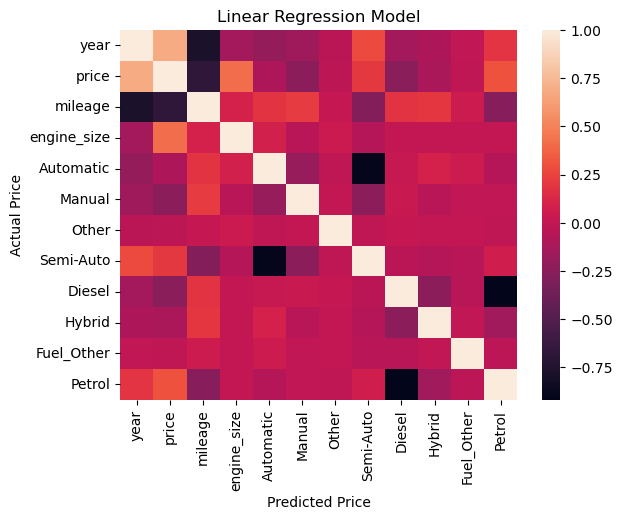

In [71]:
actual_values = Y_test
plt.scatter(predictions, actual_values, alpha=.5, color='g')
plt.xlabel('Predicted Price')
plt.ylabel('Actual Price')
plt.title('Linear Regression Model')
plt.show()

## Model Coefficients

In [73]:
feat=list(X_train.columns)
coef = model.coef_.transpose()
coef_table = np.vstack((feat, coef)).T
df = pd.DataFrame(coef_table, columns=['Feature', 'Coefficients'])
df

,Feature,Coefficients
0,year,1869.6088865177612
1,mileage,-0.14700064904364646
2,engine_size,10248.641284483598


# 7. Linear Regresion Model with Lasso

In [75]:
# Importing libraries
from sklearn.linear_model import Ridge, Lasso

In [76]:
# Generating alpha array
alphas = np.linspace(1, 0.01, 10)
alphas

array([1.  , 0.89, 0.78, 0.67, 0.56, 0.45, 0.34, 0.23, 0.12, 0.01])

In [77]:
# Loading dataset
df = pd.read_csv('cleaned_Group5_data.csv')
df.drop(columns=df.columns[0], axis=1,  inplace=True) #dropping index column
df.head()

,year,price,mileage,engine_size,Automatic,Manual,Other,Semi-Auto,Diesel,Hybrid,Fuel_Other,Petrol
0,2020,30495,1200.0,2.0,1,0,0,0,1,0,0,0
1,2020,29989,1000.0,1.5,1,0,0,0,0,0,0,1
2,2020,37899,500.0,2.0,1,0,0,0,1,0,0,0
3,2019,30399,5000.0,2.0,1,0,0,0,1,0,0,0
4,2019,29899,4500.0,2.0,1,0,0,0,1,0,0,0


## Splitting the dataset into training and test

In [79]:
y = df['price']
x = df.drop('price', axis = 1)
x.head()

,year,mileage,engine_size,Automatic,Manual,Other,Semi-Auto,Diesel,Hybrid,Fuel_Other,Petrol
0,2020,1200.0,2.0,1,0,0,0,1,0,0,0
1,2020,1000.0,1.5,1,0,0,0,0,0,0,1
2,2020,500.0,2.0,1,0,0,0,1,0,0,0
3,2019,5000.0,2.0,1,0,0,0,1,0,0,0
4,2019,4500.0,2.0,1,0,0,0,1,0,0,0


In [80]:
# Importing 'train_test_split'
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.25, random_state=42)

print("Training and Testing split was successful")

Training and Testing split was successful


## Modelling

In [82]:
# Finding out the best alpha to use
rmse_list = []
r2_list = []

for a in alphas:
    lasso = Lasso(alpha = a, max_iter=1000)
    lasso.fit(X_train,Y_train)
    pred = lasso.predict(X_test)
    
    r2_list.append(lasso.score(X_test,Y_test))
    rmse = mean_squared_error(Y_test, pred)**0.5;
    rmse_list.append(rmse)
    
lasso_result = np.vstack((alphas, rmse_list, r2_list)).T
lasso_df = pd.DataFrame(lasso_result, columns=['Alpha', 'RMSE', 'R2'])
lasso_df

,Alpha,RMSE,R2
0,1.00,4635.403033,0.756920
1,0.89,4635.397789,0.756921
2,0.78,4635.393647,0.756921
3,0.67,4635.390617,0.756922
4,0.56,4635.388647,0.756922
5,0.45,4635.387777,0.756922
6,0.34,4635.387997,0.756922
7,0.23,4635.389315,0.756922
8,0.12,4635.391720,0.756922
9,0.01,4635.403110,0.756920


From the table above it's possible to infer that the best alpha is 0.45, because it has the minor RMSE value and the higher R2 value.

## Calculating Rˆ2, RMSE and Coefficients

In [85]:
lasso = Lasso(alpha = 0.45)
lasso.fit(X_train,Y_train)

# get the predictions for the test dataset
pred = lasso.predict(X_test)
print("R^2:", lasso.score(X_test,Y_test))
print("RMSE:", mean_squared_error(Y_test, pred)**0.5)
print(pd.Series(lasso.coef_, index=x.columns))

R^2: 0.7569220556011638
RMSE: 4635.387776931585
year           1953.640947
mileage          -0.123043
engine_size    8510.679556
Automatic       624.779331
Manual        -2221.068695
Other         -4374.396455
Semi-Auto       189.645617
Diesel        -1565.338789
Hybrid        -1262.133418
Fuel_Other        0.000000
Petrol          690.269732
dtype: float64


## Plotting Predicted vs Actual

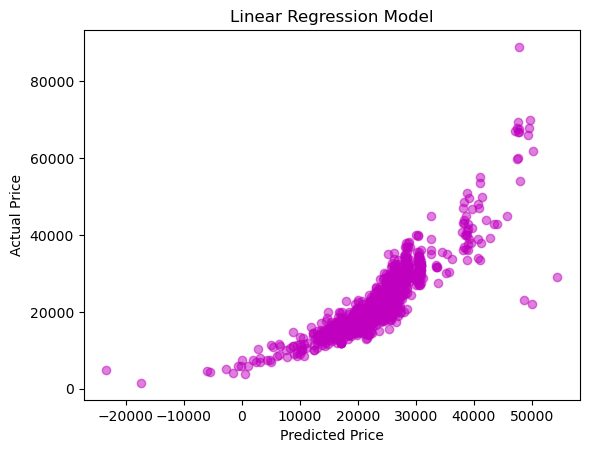

In [87]:
actual_values = Y_test
plt.scatter(pred, actual_values, alpha=.5, color='m')
plt.xlabel('Predicted Price')
plt.ylabel('Actual Price')
plt.title('Linear Regression Model')
plt.show()

# 8. Simple Polynomial Regression Model

In [89]:
# Importing libraries
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

## Defining dataset

In [91]:
df = df=df[['price','mileage','engine_size','year']]
df.head()

,price,mileage,engine_size,year
0,30495,1200.0,2.0,2020
1,29989,1000.0,1.5,2020
2,37899,500.0,2.0,2020
3,30399,5000.0,2.0,2019
4,29899,4500.0,2.0,2019


## Splitting the dataset into training and test

In [93]:
y = df['price']
X = df.drop('price',axis=1)

poly = PolynomialFeatures(degree = 2) #assigning degree 2
X = poly.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Modelling

In [95]:
model = LinearRegression()
model.fit(X_train, y_train)
predicted_y = model.predict(X_test)

## R Square

In [97]:
r2_train = model.score(X_train,y_train)
print("R^2 in Training Set:", r2_train)

r2_test = model.score(X_test,y_test)
print("R^2 in Testing Set:", r2_test)

R^2 in Training Set: 0.8484009920386495
R^2 in Testing Set: 0.8518881519512751


## RSME

In [99]:
mse = mean_squared_error(Y_test, predicted_y)

print('RMSE is :', mse**0.5)

RMSE is : 3618.3301761590837


## Plotting Predicted vs Actual

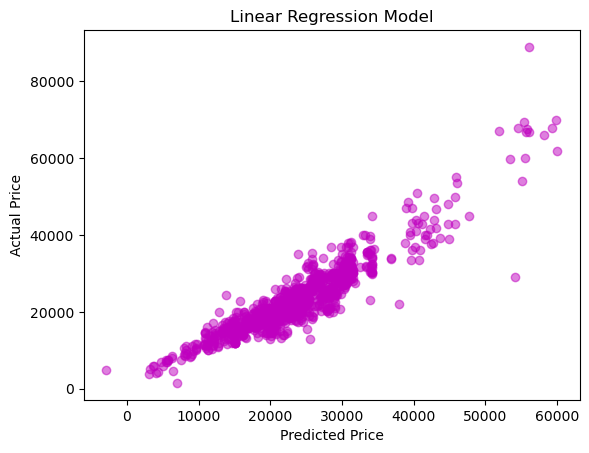

In [101]:
actual_values = y_test
plt.scatter(predicted_y, actual_values, alpha=.5, color='m')
plt.xlabel('Predicted Price')
plt.ylabel('Actual Price')
plt.title('Linear Regression Model')
plt.show()